# Reporting Results


> Envelope baseline

First reporting on the accuracies:

- load all subject summaries from `all_subs/sub-xxx/`
- keep only subjects with scalp EEG (`meta.eeg_config.scalp_only == True`)
- extract two-talker decoding accuracy from `summary_two_talker`
- color subjects by hearing group: normal hearing (NH) vs hearing impaired (HI)
- plot subject-wise decoding accuracy with a 50% chance-level line
- save a CSV table and figure for reporting

The same structure can later be reused for envelope+onsets and gamma by changing the folder/pattern configuration.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Path setup
# --------------------------------------------------
# Assumes the notebook is inside the statistics folder.
# If you run it from statistics/, this will work directly.

STAT_DIR = Path.cwd()
PROJECT_ROOT = STAT_DIR.parent

# Input file from combine_results.py
TRIAL_RESULTS_PATH = STAT_DIR / "aad_trial_level_results.csv"

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

print("Statistics folder:", STAT_DIR)
print("Project root:", PROJECT_ROOT)
print("Trial results file:", TRIAL_RESULTS_PATH)
print("Figure output folder:", REPORT_FIG_DIR)

Statistics folder: c:\Projects\AAD_Fagprojekt_v2\statistics
Project root: c:\Projects\AAD_Fagprojekt_v2
Trial results file: c:\Projects\AAD_Fagprojekt_v2\statistics\aad_trial_level_results.csv
Figure output folder: c:\Projects\AAD_Fagprojekt_v2\reports\figures


In [2]:
trial_df = pd.read_csv(TRIAL_RESULTS_PATH)

print("Trial-level shape:", trial_df.shape)
display(trial_df.head())

# Keep only scalp-EEG model outputs
trial_df = trial_df[trial_df["scalp_only"] == True].copy()

print("\nNumber of subjects after filtering:", trial_df["subject"].nunique())
print("\nSubjects by hearing status:")
display(trial_df.groupby("hearing_status")["subject"].nunique())

# One row per subject for subject-wise accuracy plotting
subject_acc_df = (
    trial_df.groupby(["subject", "hearing_status", "group_HI"], as_index=False)
    .agg(
        decoding_accuracy=("correct", "mean"),
        n_trials=("correct", "size"),
        n_correct=("correct", "sum"),
    )
)

# Nice labels
subject_acc_df["group_label"] = subject_acc_df["hearing_status"].str.upper()

# Subject number for sorting
subject_acc_df["subject_num"] = (
    subject_acc_df["subject"].str.extract(r"(\d+)").astype(int)
)

# Sort HI first, then NH, or reverse if you prefer
subject_acc_df["group_order"] = subject_acc_df["group_label"].map({"HI": 0, "NH": 1})
subject_acc_df = subject_acc_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

display(subject_acc_df.head())

Trial-level shape: (1408, 13)


,subject,hearing_status,group_HI,scalp_only,trial_index,r_att,r_ign,r_diff,correct,subject_decoding_accuracy,subject_n_trials,subject_n_correct,summary_path
0,sub-001,hi,1,True,0,0.108249,0.046398,0.061851,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
1,sub-001,hi,1,True,1,0.154476,0.016525,0.137951,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
2,sub-001,hi,1,True,2,0.071035,-0.007117,0.078152,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
3,sub-001,hi,1,True,3,0.117353,0.083574,0.033779,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
4,sub-001,hi,1,True,4,0.070426,-0.034507,0.104933,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...



Number of subjects after filtering: 44

Subjects by hearing status:


hearing_status
hi    22
nh    22
Name: subject, dtype: int64

,subject,hearing_status,group_HI,decoding_accuracy,n_trials,n_correct,group_label,subject_num,group_order
0,sub-001,hi,1,0.96875,32,31,HI,1,0
1,sub-002,hi,1,1.00000,32,32,HI,2,0
2,sub-003,hi,1,0.75000,32,24,HI,3,0
3,sub-004,hi,1,0.90625,32,29,HI,4,0
4,sub-005,hi,1,0.90625,32,29,HI,5,0


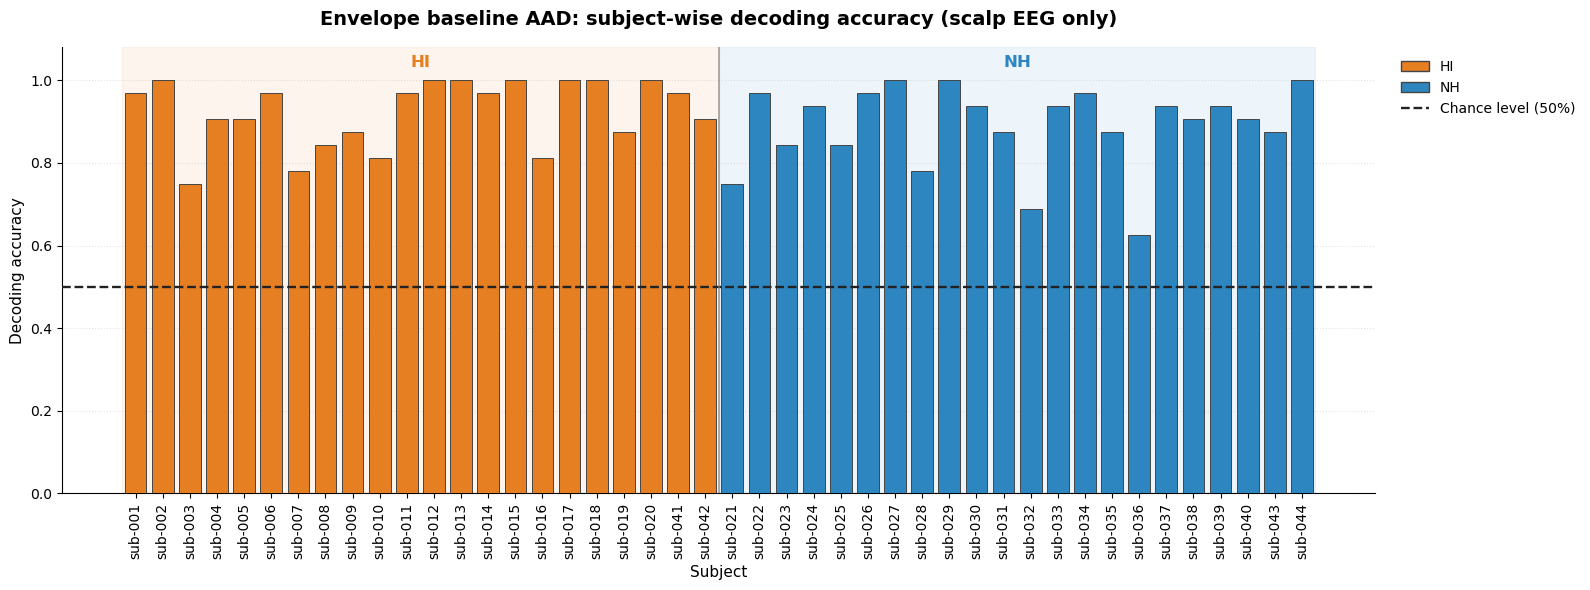

Saved figure to:
c:\Projects\AAD_Fagprojekt_v2\reports\figures\baseline_accuracy_plot.png
c:\Projects\AAD_Fagprojekt_v2\reports\figures\baseline_accuracy_plot.pdf


In [5]:
# --------------------------------------------------
# Plot subject-wise decoding accuracy
# --------------------------------------------------

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Colors
COLOR_HI = "#E67E22"   # orange
COLOR_NH = "#2E86C1"   # blue
COLOR_CHANCE = "#222222"

# Make sure subjects are sorted clearly
plot_df = subject_acc_df.copy()

plot_df["subject_num"] = plot_df["subject"].str.extract(r"(\d+)").astype(int)
plot_df["group_order"] = plot_df["group_label"].map({"HI": 0, "NH": 1})
plot_df = plot_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

# Bar positions and colors
x = np.arange(len(plot_df))
bar_colors = plot_df["group_label"].map({"HI": COLOR_HI, "NH": COLOR_NH})

fig, ax = plt.subplots(figsize=(16, 6))

# Light background shading for the two groups
hi_count = (plot_df["group_label"] == "HI").sum()
nh_count = (plot_df["group_label"] == "NH").sum()

if hi_count > 0:
    ax.axvspan(-0.5, hi_count - 0.5, color=COLOR_HI, alpha=0.08, zorder=0)

if nh_count > 0:
    ax.axvspan(hi_count - 0.5, len(plot_df) - 0.5, color=COLOR_NH, alpha=0.08, zorder=0)

# Bars
ax.bar(
    x,
    plot_df["decoding_accuracy"],
    color=bar_colors,
    edgecolor="#444444",
    linewidth=0.7,
    zorder=3,
)

# Chance level
ax.axhline(
    0.5,
    color=COLOR_CHANCE,
    linestyle="--",
    linewidth=1.7,
    label="Chance level (50%)",
    zorder=4,
)

# Separator between HI and NH
if hi_count > 0 and nh_count > 0:
    ax.axvline(
        hi_count - 0.5,
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=5,
    )

# Group labels above plot
if hi_count > 0:
    ax.text(
        (hi_count - 1) / 2,
        1.025,
        "HI",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_HI,
    )

if nh_count > 0:
    ax.text(
        hi_count + (nh_count - 1) / 2,
        1.025,
        "NH",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_NH,
    )

# Axis formatting
ax.set_title(
    "Envelope baseline AAD: subject-wise decoding accuracy (scalp EEG only)",
    fontsize=14,
    weight="bold",
    pad=16,
)

ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel("Decoding accuracy", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["subject"], rotation=90)

ax.set_ylim(0, 1.08)
ax.yaxis.grid(True, linestyle=":", alpha=0.35, zorder=1)
ax.set_axisbelow(True)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plotting area
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_handles = [
    Patch(facecolor=COLOR_HI, edgecolor="#444444", label="HI"),
    Patch(facecolor=COLOR_NH, edgecolor="#444444", label="NH"),
    Line2D([0], [0], color=COLOR_CHANCE, linestyle="--", linewidth=1.7, label="Chance level (50%)"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
)

fig.tight_layout()

# Save figure
out_png = REPORT_FIG_DIR / "baseline_accuracy_plot.png"
out_pdf = REPORT_FIG_DIR / "baseline_accuracy_plot.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved figure to:")
print(out_png)
print(out_pdf)